# YOLOv8 확인하기

In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 8.8 MB/s eta 0:00:00


### Yolo 이해

In [2]:
from ultralytics import YOLO

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
model = YOLO('yolov8n.pt')

In [5]:
example_imgs = ['https://ultralytics.com/images/bus.jpg']

In [4]:
from PIL import Image
import requests
from io import BytesIO

In [6]:
response = requests.get(example_imgs[0])
img = Image.open(BytesIO(response.content))

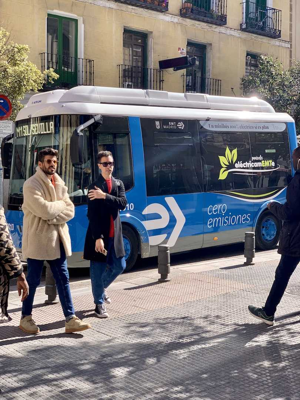

In [7]:
img.thumbnail((400,400))
img

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
results = model.predict(example_imgs[0], save=True, conf=0.25)


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 7.0ms
Speed: 125.4ms preprocess, 7.0ms inference, 46.4ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


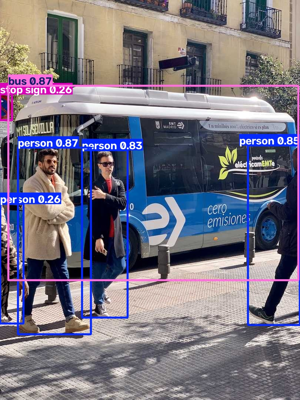

In [10]:
output_img = Image.open('./runs/detect/predict/bus.jpg')
output_img.thumbnail((400,400))
output_img

In [11]:
results

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 

In [12]:
type(results)

list

In [13]:
type(results[0])

ultralytics.engine.results.Results

In [14]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 5.,  0.,  0.,  0.,  0., 11.], device='cuda:0')
conf: tensor([0.8734, 0.8657, 0.8528, 0.8252, 0.2611, 0.2551], device='cuda:0')
data: tensor([[2.2871e+01, 2.3128e+02, 8.0500e+02, 7.5684e+02, 8.7345e-01, 5.0000e+00],
        [4.8550e+01, 3.9855e+02, 2.4535e+02, 9.0270e+02, 8.6569e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7704e+02, 8.5284e-01, 0.0000e+00],
        [2.2152e+02, 4.0580e+02, 3.4497e+02, 8.5754e+02, 8.2522e-01, 0.0000e+00],
        [0.0000e+00, 5.5053e+02, 6.3007e+01, 8.7344e+02, 2.6111e-01, 0.0000e+00],
        [5.8167e-02, 2.5446e+02, 3.2557e+01, 3.2487e+02, 2.5507e-01, 1.1000e+01]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([6, 6])
xywh: tensor([[413.9369, 494.0589, 782.1313, 525.5631],
        [146.9480, 650.6274, 196.7951, 504.1505],
        [739.5966, 634.6108, 140.2473, 484.8493],
        [283.2440, 631.6676, 123.4533, 451.7380],
    

In [15]:
url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml"

In [16]:
import yaml
import requests

url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml"

response = requests.get(url)
data = yaml.safe_load(response.text)

print(data)

{'path': 'coco', 'train': 'train2017.txt', 'val': 'val2017.txt', 'test': 'test-dev2017.txt', 'names': {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toi

In [17]:
results[0].boxes.conf

tensor([0.8734, 0.8657, 0.8528, 0.8252, 0.2611, 0.2551], device='cuda:0')

In [18]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([ 5.,  0.,  0.,  0.,  0., 11.], device='cuda:0')
conf: tensor([0.8734, 0.8657, 0.8528, 0.8252, 0.2611, 0.2551], device='cuda:0')
data: tensor([[2.2871e+01, 2.3128e+02, 8.0500e+02, 7.5684e+02, 8.7345e-01, 5.0000e+00],
        [4.8550e+01, 3.9855e+02, 2.4535e+02, 9.0270e+02, 8.6569e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7704e+02, 8.5284e-01, 0.0000e+00],
        [2.2152e+02, 4.0580e+02, 3.4497e+02, 8.5754e+02, 8.2522e-01, 0.0000e+00],
        [0.0000e+00, 5.5053e+02, 6.3007e+01, 8.7344e+02, 2.6111e-01, 0.0000e+00],
        [5.8167e-02, 2.5446e+02, 3.2557e+01, 3.2487e+02, 2.5507e-01, 1.1000e+01]], device='cuda:0')
id: None
is_track: False
orig_shape: (1080, 810)
shape: torch.Size([6, 6])
xywh: tensor([[413.9369, 494.0589, 782.1313, 525.5631],
        [146.9480, 650.6274, 196.7951, 504.1505],
        [739.5966, 634.6108, 140.2473, 484.8493],
        [283.2440, 631.6676, 123.4533, 451.7380],
    

In [19]:
img.size

(300, 400)

In [20]:
results[0].boxes.xywh

tensor([[413.9369, 494.0589, 782.1313, 525.5631],
        [146.9480, 650.6274, 196.7951, 504.1505],
        [739.5966, 634.6108, 140.2473, 484.8493],
        [283.2440, 631.6676, 123.4533, 451.7380],
        [ 31.5035, 711.9840,  63.0069, 322.9177],
        [ 16.3078, 289.6668,  32.4992,  70.4147]], device='cuda:0')

In [21]:
results[0].boxes.xywhn

tensor([[0.5110, 0.4575, 0.9656, 0.4866],
        [0.1814, 0.6024, 0.2430, 0.4668],
        [0.9131, 0.5876, 0.1731, 0.4489],
        [0.3497, 0.5849, 0.1524, 0.4183],
        [0.0389, 0.6592, 0.0778, 0.2990],
        [0.0201, 0.2682, 0.0401, 0.0652]], device='cuda:0')

In [22]:
import cv2
import requests
import numpy as np
from PIL import Image
from io import BytesIO

img_url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(img_url)
img = Image.open(BytesIO(response.content)).convert("RGB")
img_np = np.array(img)
height, width = img_np.shape[:2]

In [23]:
height, width

(1080, 810)

In [24]:
bbox1 = results[0].boxes.xywh[0]
bbox1

tensor([413.9369, 494.0589, 782.1313, 525.5631], device='cuda:0')

In [25]:
bbox1[0]/width, bbox1[1]/height, bbox1[2]/width, bbox1[3]/height

(tensor(0.5110, device='cuda:0'),
 tensor(0.4575, device='cuda:0'),
 tensor(0.9656, device='cuda:0'),
 tensor(0.4866, device='cuda:0'))

In [26]:
results[0].boxes.xywhn

tensor([[0.5110, 0.4575, 0.9656, 0.4866],
        [0.1814, 0.6024, 0.2430, 0.4668],
        [0.9131, 0.5876, 0.1731, 0.4489],
        [0.3497, 0.5849, 0.1524, 0.4183],
        [0.0389, 0.6592, 0.0778, 0.2990],
        [0.0201, 0.2682, 0.0401, 0.0652]], device='cuda:0')

In [27]:
bbox2 = results[0].boxes.xyxy[0]
bbox2

tensor([ 22.8713, 231.2773, 805.0026, 756.8405], device='cuda:0')

In [28]:
bbox2[0]/width, bbox2[1]/height, bbox2[2]/width, bbox2[3]/height

(tensor(0.0282, device='cuda:0'),
 tensor(0.2141, device='cuda:0'),
 tensor(0.9938, device='cuda:0'),
 tensor(0.7008, device='cuda:0'))

In [29]:
results[0].boxes.xyxyn[0]

tensor([0.0282, 0.2141, 0.9938, 0.7008], device='cuda:0')

### 시각화

In [30]:
url = "https://ultralytics.com/images/bus.jpg"
response = requests.get(url)
img = np.array(Image.open(BytesIO(response.content)).convert("RGB"))
h, w = img.shape[:2]
img_copy = img.copy()

In [31]:
xyxy_coordinate = results[0].boxes.xyxy.cpu().numpy()

In [32]:
xyxy_coordinate

array([[     22.871,      231.28,         805,      756.84],
       [      48.55,      398.55,      245.35,       902.7],
       [     669.47,      392.19,      809.72,      877.04],
       [     221.52,       405.8,      344.97,      857.54],
       [          0,      550.53,      63.007,      873.44],
       [   0.058167,      254.46,      32.557,      324.87]], dtype=float32)

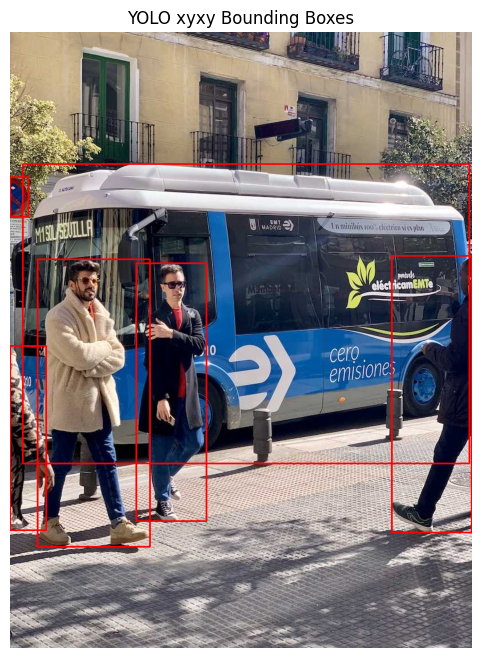

In [33]:
import matplotlib.pyplot as plt

for box in xyxy_coordinate:
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(img_copy, (x1, y1), (x2, y2), color=(255, 0, 0), thickness=2)

# 시각화
plt.figure(figsize=(10, 8))
plt.imshow(img_copy)
plt.title("YOLO xyxy Bounding Boxes")
plt.axis("off")
plt.show()

In [34]:
results[0].boxes.data

tensor([[2.2871e+01, 2.3128e+02, 8.0500e+02, 7.5684e+02, 8.7345e-01, 5.0000e+00],
        [4.8550e+01, 3.9855e+02, 2.4535e+02, 9.0270e+02, 8.6569e-01, 0.0000e+00],
        [6.6947e+02, 3.9219e+02, 8.0972e+02, 8.7704e+02, 8.5284e-01, 0.0000e+00],
        [2.2152e+02, 4.0580e+02, 3.4497e+02, 8.5754e+02, 8.2522e-01, 0.0000e+00],
        [0.0000e+00, 5.5053e+02, 6.3007e+01, 8.7344e+02, 2.6111e-01, 0.0000e+00],
        [5.8167e-02, 2.5446e+02, 3.2557e+01, 3.2487e+02, 2.5507e-01, 1.1000e+01]], device='cuda:0')

In [35]:
det = results[0].boxes.data.cpu().numpy()

In [36]:
type(det)

numpy.ndarray

In [37]:
type(det)

numpy.ndarray

In [38]:
url = "https://raw.githubusercontent.com/ultralytics/ultralytics/main/ultralytics/cfg/datasets/coco.yaml"

# URL에서 YAML 텍스트 불러오기
response = requests.get(url)
yaml_content = response.text

# YAML 파싱
parsed = yaml.safe_load(yaml_content)

# 클래스 이름 추출
class_names = parsed['names']


In [39]:
class_names

{0: 'person',
 1: 'bicycle',
 2: 'car',
 3: 'motorcycle',
 4: 'airplane',
 5: 'bus',
 6: 'train',
 7: 'truck',
 8: 'boat',
 9: 'traffic light',
 10: 'fire hydrant',
 11: 'stop sign',
 12: 'parking meter',
 13: 'bench',
 14: 'bird',
 15: 'cat',
 16: 'dog',
 17: 'horse',
 18: 'sheep',
 19: 'cow',
 20: 'elephant',
 21: 'bear',
 22: 'zebra',
 23: 'giraffe',
 24: 'backpack',
 25: 'umbrella',
 26: 'handbag',
 27: 'tie',
 28: 'suitcase',
 29: 'frisbee',
 30: 'skis',
 31: 'snowboard',
 32: 'sports ball',
 33: 'kite',
 34: 'baseball bat',
 35: 'baseball glove',
 36: 'skateboard',
 37: 'surfboard',
 38: 'tennis racket',
 39: 'bottle',
 40: 'wine glass',
 41: 'cup',
 42: 'fork',
 43: 'knife',
 44: 'spoon',
 45: 'bowl',
 46: 'banana',
 47: 'apple',
 48: 'sandwich',
 49: 'orange',
 50: 'broccoli',
 51: 'carrot',
 52: 'hot dog',
 53: 'pizza',
 54: 'donut',
 55: 'cake',
 56: 'chair',
 57: 'couch',
 58: 'potted plant',
 59: 'bed',
 60: 'dining table',
 61: 'toilet',
 62: 'tv',
 63: 'laptop',
 64: 'mou

데이터 클래스를 확인하였다
-> 시나리오 기반으로 생각할때는 필요없는 클래스들이 많아보인다
=> 액션

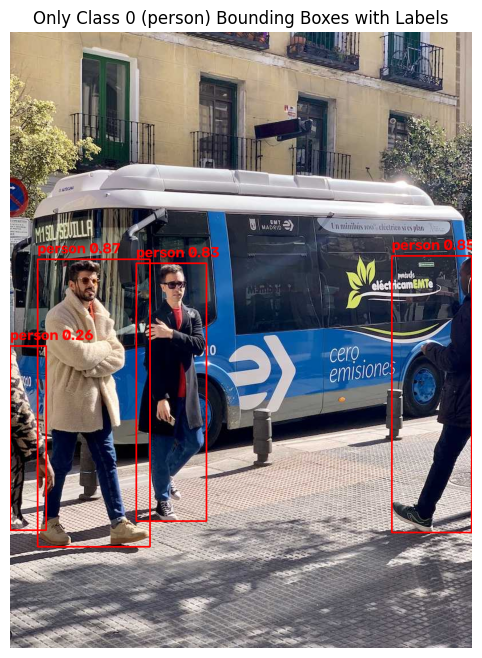

In [40]:
img_copy = img_np.copy()


for det in results[0].boxes.data:
    x1, y1, x2, y2, conf, cls = det.tolist()
    if int(cls) == 0:
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        label = f"{class_names[int(cls)]} {conf:.2f}"
        cv2.rectangle(img_copy, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img_copy, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.9, (255, 0, 0), 2)


plt.figure(figsize=(10, 8))
plt.imshow(img_copy)
plt.title("Only Class 0 (person) Bounding Boxes with Labels")
plt.axis("off")
plt.show()

반쯤 가려진 사람도 잘 찾았다.
버스는 찾지않아도 되니까 결과 시각화에서 제외한다.
목표(시나리오)에 따르면 표지판에 대해서 찾을 수 있어야한다. -> 어떤 작업이 필요한ㄷ가?

In [41]:
import os
bus_class_id = [k for k, v in class_names.items() if v == 'bus'][0]
os.makedirs("bus_crops", exist_ok=True)

count = 0
for det in results[0].boxes.data:
    x1, y1, x2, y2, conf, cls = det.tolist()
    if int(cls) == bus_class_id:
        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])
        cropped = img_np[y1:y2, x1:x2]
        save_path = f"bus_crops/bus_crop_{count}.jpg"
        cv2.imwrite(save_path, cv2.cvtColor(cropped, cv2.COLOR_RGB2BGR))
        print(f"버스 {count}번 잘라서 저장: {save_path}")
        count += 1

버스 0번 잘라서 저장: bus_crops/bus_crop_0.jpg


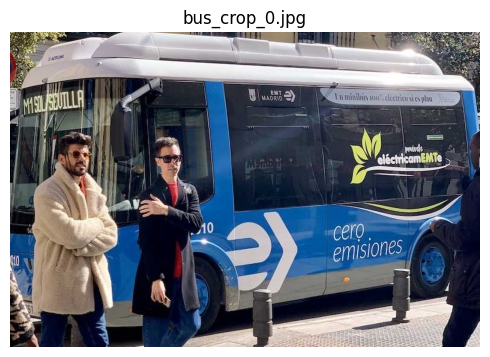

In [42]:
import os
import cv2
import matplotlib.pyplot as plt

crop_folder = "bus_crops"

image_files = sorted([f for f in os.listdir(crop_folder) if f.endswith(".jpg")])

num_images = len(image_files)
plt.figure(figsize=(5 * num_images, 5))

for i, filename in enumerate(image_files):
    img_path = os.path.join(crop_folder, filename)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # OpenCV는 BGR로 불러오기 때문에 RGB로 변환

    plt.subplot(1, num_images, i + 1)
    plt.imshow(img)
    plt.title(filename)
    plt.axis("off")

plt.tight_layout()
plt.show()


# YOLOv8 학습 실습

#### 데이터셋 다운로드
https://universe.roboflow.com/warisara-kaewsuwan-cf2hs/stamp-bcrhe

![image-3.png](attachment:image-3.png)

In [46]:
from ultralytics import YOLO
from pathlib import Path
import os
import yaml
from ultralytics.data.utils import check_det_dataset

model = YOLO("yolov8n.pt")

# 한글 폴더명의 숨은 문자 차이를 피하려고 실제 파일 경로 탐색
source_yamls = list(Path("/content/drive/MyDrive/Colab Notebooks").rglob("stamp.v10i.yolov8/data.yaml"))
assert len(source_yamls) == 1, f"데이터셋 후보가 1개여야 합니다: {source_yamls}"
DATASET_DIR = source_yamls[0].parent
source_yaml = DATASET_DIR / "data.yaml"
assert source_yaml.is_file(), f"데이터셋 설정 파일 없음: {source_yaml}"

# 원본 Drive YAML은 보존하고 Colab 임시 저장소에 경로 보정본 생성
dataset_config = yaml.safe_load(source_yaml.read_text(encoding="utf-8"))
dataset_config.update({
    "path": str(DATASET_DIR),
    "train": "train/images",
    "val": "valid/images",
    "test": "test/images",
})
DATA_YAML = "/content/stamp_data.yaml"
Path(DATA_YAML).write_text(yaml.safe_dump(dataset_config, allow_unicode=True, sort_keys=False), encoding="utf-8")

# 학습 없이 파일 위치와 이미지/라벨 짝 확인
print(f"데이터셋: {DATASET_DIR}")
for split in ("train", "valid", "test"):
    image_dir = DATASET_DIR / split / "images"
    label_dir = DATASET_DIR / split / "labels"
    assert image_dir.is_dir() and label_dir.is_dir(), f"폴더 없음: {split}"
    images = [p for p in image_dir.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}]
    labels = {p.stem for p in label_dir.glob("*.txt")}
    missing = [p.name for p in images if p.stem not in labels]
    assert images and not missing, f"{split}: 이미지 없음 또는 라벨 누락 {missing[:5]}"
    print(f"{split}: images={len(images)}, labels={len(labels)}, missing_labels={len(missing)}")
checked_data = check_det_dataset(DATA_YAML, autodownload=False)
print("클래스:", checked_data["names"])
print("검증 완료:", DATA_YAML)

데이터셋: /content/drive/MyDrive/Colab Notebooks/컴퓨터 비전 /제조기반/제조기반/stamp.v10i.yolov8
train: images=1100, labels=1100, missing_labels=0
valid: images=273, labels=273, missing_labels=0
test: images=193, labels=193, missing_labels=0
클래스: {0: 'shoes', 1: 'stamp'}
검증 완료: /content/stamp_data.yaml


* `datasets`
    * `stamp`
        * `test`
        * `train`
        * `valid`
        * `data.yaml`

In [47]:
model.train(data=DATA_YAML, epochs=20, imgsz=640, batch=16, name="stamp_detect", device=0)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/stamp_data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=stamp_detect-2, nbs=64, nms=None, opset=None, optim

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7edaa63d47d0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

In [48]:
metrics = model.val()
print("🔍 평가 결과:", metrics)

Ultralytics 8.4.156 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.4±0.1 ms, read: 34.0±7.8 MB/s, size: 26.6 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips
val: Scanning /content/drive/MyDrive/Colab Notebooks/컴퓨터 비전 /제조기반/제조기반/stamp.v10i.yolov8/valid/labels.cache... 273 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 273/273 81.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 18/18 4.8it/s 3.8s
                   all        273        952      0.957      0.978      0.987      0.619
                 shoes        204        408      0.941      0.956      0.978      0.712
                 stamp        273        544      0.973          1      0.995      0.526


In [56]:
import pandas as pd
from pathlib import Path
from IPython.display import display, Markdown

# 숫자를 직접 입력하지 않고, 바로 위 model.val()의 실제 결과를 사용합니다.
box = metrics.box
class_ids = [int(c) for c in box.ap_class_index]

# 검증 이미지 총수는 검증 폴더에서 계산합니다. 클래스별 Images는 중복될 수 있습니다.
val_dir = Path(checked_data["val"])
image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
n_val_images = sum(p.is_file() and p.suffix.lower() in image_extensions for p in val_dir.rglob("*"))

rows = [{
    "Class": "all",
    "Images": n_val_images,
    "Instances": int(metrics.nt_per_class.sum()),
    "Precision": float(box.mp),
    "Recall": float(box.mr),
    "mAP@.5": float(box.map50),
    "mAP@.5:.95": float(box.map),
}]

for i, class_id in enumerate(class_ids):
    rows.append({
        "Class": metrics.names[class_id],
        "Images": int(metrics.nt_per_image[class_id]),
        "Instances": int(metrics.nt_per_class[class_id]),
        "Precision": float(box.p[i]),
        "Recall": float(box.r[i]),
        "mAP@.5": float(box.ap50[i]),
        "mAP@.5:.95": float(box.ap[i]),
    })

df = pd.DataFrame(rows)

# 전체 성능이 model.val()의 원본 결과와 일치하는지 검증합니다.
metric_keys = {"Precision": "metrics/precision(B)", "Recall": "metrics/recall(B)",
               "mAP@.5": "metrics/mAP50(B)", "mAP@.5:.95": "metrics/mAP50-95(B)"}
assert all(abs(df.loc[0, col] - metrics.results_dict[key]) < 1e-12 for col, key in metric_keys.items())

display(Markdown("### 실제 검증 결과 (model.val)"))
display(Markdown(df.to_markdown(index=False, floatfmt=".4f")))
print("검증 완료: 전체 성능 4개 항목이 metrics.results_dict와 일치합니다.")
display(Markdown("""
- **Images / Instances**: 평가 이미지 수 / 정답 객체 수. 클래스별 이미지 수는 서로 겹칠 수 있습니다.
- **Precision**: 탐지했다고 예측한 객체 중 맞은 비율.
- **Recall**: 실제 객체 중 찾아낸 비율.
- **mAP@.5**: IoU 0.5 기준의 평균 탐지 성능.
- **mAP@.5:.95**: IoU 0.5~0.95의 여러 기준을 평균한 더 엄격한 탐지 성능.
- `all`의 성능은 클래스별 평균이며, 위 평가 셀을 다시 실행한 뒤 이 셀을 실행하면 새 결과로 갱신됩니다.
"""))

### 실제 검증 결과 (model.val)

| Class   |   Images |   Instances |   Precision |   Recall |   mAP@.5 |   mAP@.5:.95 |
|:--------|---------:|------------:|------------:|---------:|---------:|-------------:|
| all     |      273 |         952 |      0.9568 |   0.9779 |   0.9866 |       0.6191 |
| shoes   |      204 |         408 |      0.9407 |   0.9559 |   0.9783 |       0.7120 |
| stamp   |      273 |         544 |      0.9730 |   1.0000 |   0.9950 |       0.5262 |

검증 완료: 전체 성능 4개 항목이 metrics.results_dict와 일치합니다.



- **Images / Instances**: 평가 이미지 수 / 정답 객체 수. 클래스별 이미지 수는 서로 겹칠 수 있습니다.
- **Precision**: 탐지했다고 예측한 객체 중 맞은 비율.
- **Recall**: 실제 객체 중 찾아낸 비율.
- **mAP@.5**: IoU 0.5 기준의 평균 탐지 성능.
- **mAP@.5:.95**: IoU 0.5~0.95의 여러 기준을 평균한 더 엄격한 탐지 성능.
- `all`의 성능은 클래스별 평균이며, 위 평가 셀을 다시 실행한 뒤 이 셀을 실행하면 새 결과로 갱신됩니다.


In [50]:
metrics.box.map, metrics.box.map50, metrics.box.map75, metrics.box.maps

(np.float64(0.6191039095483802),
 np.float64(0.9866305153559178),
 np.float64(0.6585571564483287),
 array([    0.71205,     0.52616]))

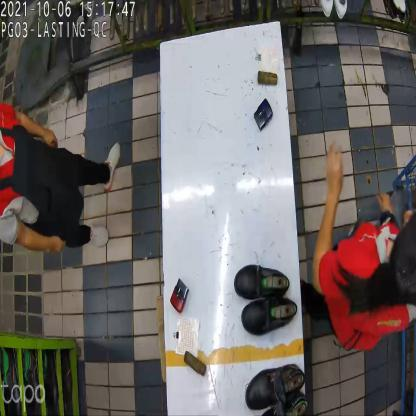

In [52]:
from PIL import Image
import matplotlib.pyplot as plt

test_image_path = DATASET_DIR / "test" / "images" / "clip1_mp4-33_jpg.rf.95be2fb4fbae44fb12fd600d1d966f76.jpg"
assert test_image_path.is_file(), f"테스트 이미지 없음: {test_image_path}"
image = Image.open(test_image_path)

image

In [53]:
results = model.predict(str(test_image_path))
results[0].save(filename='predicted1.jpg')


image 1/1 /content/drive/MyDrive/Colab Notebooks/컴퓨터 비전 /제조기반/제조기반/stamp.v10i.yolov8/test/images/clip1_mp4-33_jpg.rf.95be2fb4fbae44fb12fd600d1d966f76.jpg: 640x640 1 shoes, 2 stamps, 7.2ms
Speed: 1.7ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


'predicted1.jpg'

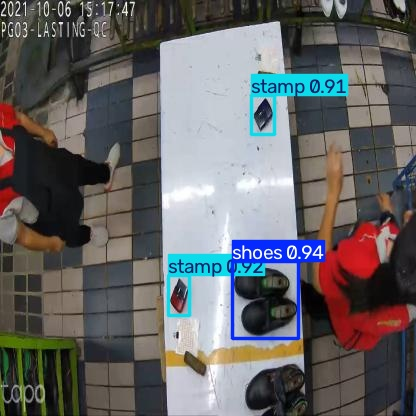

In [54]:
from PIL import Image
import matplotlib.pyplot as plt

image = Image.open("predicted1.jpg")

image

In [55]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([0., 1., 1.], device='cuda:0')
conf: tensor([0.9400, 0.9205, 0.9099], device='cuda:0')
data: tensor([[232.3693, 261.2703, 298.5098, 338.4912,   0.9400,   0.0000],
        [168.6547, 275.1891, 189.9182, 315.9040,   0.9205,   1.0000],
        [251.9681,  95.0789, 274.3316, 134.4557,   0.9099,   1.0000]], device='cuda:0')
id: None
is_track: False
orig_shape: (416, 416)
shape: torch.Size([3, 6])
xywh: tensor([[265.4395, 299.8808,  66.1405,  77.2209],
        [179.2864, 295.5465,  21.2635,  40.7149],
        [263.1498, 114.7673,  22.3636,  39.3768]], device='cuda:0')
xywhn: tensor([[0.6381, 0.7209, 0.1590, 0.1856],
        [0.4310, 0.7104, 0.0511, 0.0979],
        [0.6326, 0.2759, 0.0538, 0.0947]], device='cuda:0')
xyxy: tensor([[232.3693, 261.2703, 298.5098, 338.4912],
        [168.6547, 275.1891, 189.9182, 315.9040],
        [251.9681,  95.0789, 274.3316, 134.4557]], device='cuda:0')
xyxyn: tensor([[0.5586, 0.6281, 0.71